## Phase I Project Proposal
### The effect of the 3 pointer in the NBA

#### Name: Tejadatta Kalapatapu, DS 3000, Section 8

### Introduction

The NBA has evolved drastically over the years. The newest era being controlled by the three pointer. However, at a time, there was no three pointer, only added in 1979. Since then, the amount of three's being taken per game has been on an incline, especially since the greatest shooter of all time, Stephen Curry, reached his prime in the league. What I wish to analyze is the variance of efficiency throughout the different teams shooting teams in the NBA. Furthermore, I want to find out if there is a correlation between the three point percentage for a team and their success throughout the season. These answers can be used for multiple reasons, for example, a team with a lower efficiency of threes can try to align their play style to a team that shoots threes at a very efficient rate. To add on, the second question can give teams a better idea on how many threes to really take per game to make the most out of the extra point and give them the competitive edge.

### Data collection

I am going to use a websites called teamrankings.com to get the team names, then the stats of each teams three pointers attempted, three point percentage, and the offensive efficiency. I will webscrape for all of these values using BeautifulSoup and then use the pandas package to create a dataframe with all of the stats sorted by teams.

In [10]:
#importing necessary packages
import requests
from bs4 import BeautifulSoup
import pandas as pd

#urls used 
url_3p_pct = "https://www.teamrankings.com/nba/stat/three-point-pct"
url_3pa = "https://www.teamrankings.com/nba/stat/three-pointers-attempted-per-game"
url_offensive_efficiency = "https://www.teamrankings.com/nba/stat/offensive-efficiency"

#scraping the team names and stats
def scrape_stats(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')
    
    #getting table rows
    table = soup.find('table', {'class': 'tr-table'}).find('tbody').find_all('tr')
    
    #lists for team and stats
    teams = []
    stats = []
    
    #getting the team names and stats
    for row in table:
        columns = row.find_all('td')
        team = columns[1].text.strip()
        stat = columns[2].text.strip()
        
        #cleaning the data by removing the '%' symbol and convert the value to a float
        stat = stat.replace('%', '').strip()
        teams.append(team)
        stats.append(float(stat))
    
    return teams, stats

#scraping for 3pt %, 3pa, and offensive efficiency
teams_3p_pct, stats_3p_pct = scrape_stats(url_3p_pct)
teams_3pa, stats_3pa = scrape_stats(url_3pa)
teams_efficiency, stats_efficiency = scrape_stats(url_offensive_efficiency)

#making dfs for each dataset
df_3p_pct = pd.DataFrame({'Team': teams_3p_pct, '3P%': stats_3p_pct})
df_3pa = pd.DataFrame({'Team': teams_3pa, '3PA': stats_3pa})
df_efficiency = pd.DataFrame({'Team': teams_efficiency, 'ORtg': stats_efficiency})

#merging them all together
df_merged = pd.merge(pd.merge(df_3p_pct, df_3pa, on='Team'), df_efficiency, on='Team')

#sorting in alphabetical order
df_merged = df_merged.sort_values(by='Team').reset_index(drop=True)

#converting to csv file
df_merged.to_csv('nba_shooting_and_offense.csv', index=False)

print(df_merged)

            Team   3P%   3PA   ORtg
0        Atlanta  32.1  28.0  1.113
1         Boston  43.4  53.0  1.277
2       Brooklyn  39.5  43.0  1.075
3      Charlotte  38.5  39.0  1.084
4        Chicago  29.4  34.0  1.001
5      Cleveland  46.7  30.0  1.301
6         Dallas  43.2  44.0  1.141
7         Denver  18.4  38.0  0.831
8        Detroit  27.3  33.0  1.057
9   Golden State  41.7  48.0  1.264
10       Houston  30.2  43.0  1.035
11       Indiana  29.0  31.0  1.116
12   LA Clippers  27.6  29.0  0.994
13     LA Lakers  16.7  30.0  1.096
14       Memphis  37.8  45.0  1.169
15         Miami  32.4  34.0  0.969
16     Milwaukee  43.2  37.0  1.212
17     Minnesota  36.3  45.5  1.075
18   New Orleans  37.8  37.0  1.109
19      New York  36.7  30.0  1.182
20     Okla City  22.2  36.0  0.974
21       Orlando  36.7  49.0  1.159
22  Philadelphia  25.8  31.0  1.066
23       Phoenix  39.5  38.0  1.020
24      Portland  23.5  34.0  0.939
25    Sacramento  37.9  29.0  1.102
26   San Antonio  33.3  36.0

### Data Usage

I can use this data to answer my question by comparing the amount of three pointers attempted and the three point percentage and create graphs to see what teams are shooting the most efficiently. As for my second question, the 3 pointers attempted can be compared to the offensive efficiency of each team and determine which team uses the three point line to the most of its ability by using logistical regression graphs or something similar, a supervised machine learning technique. The methods of what graphs or techniques I might use to solve my questions may change as the year goes on as I do not know too many machine learning methods yet. If I learn any relevant unsupervised methods, I will try to incorpate them into my results as well.

In [7]:
corr = df_merged.corr(numeric_only = True)
print(corr)

           3P%       3PA      ORtg
3P%   1.000000  0.331471  0.732834
3PA   0.331471  1.000000  0.251394
ORtg  0.732834  0.251394  1.000000


<Axes: >

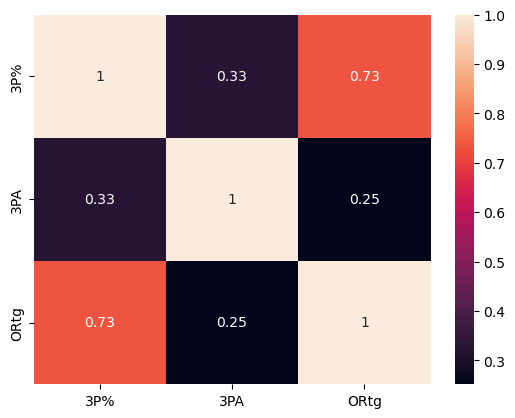

In [44]:
import seaborn as sns
sns.heatmap(corr, annot = True)

Text(0.5, 1.0, 'Precentage of 3 Pointers Made V.S. 3 Pointers Attempted')

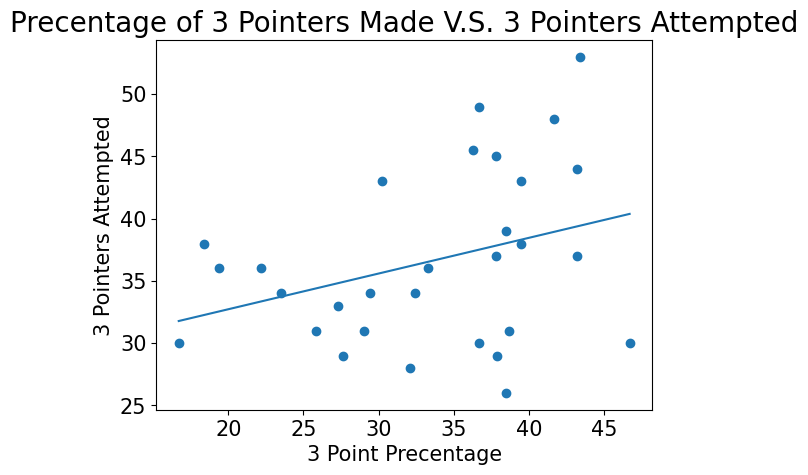

In [80]:
import matplotlib.pyplot as plt
import numpy as np
plt.scatter(df_merged['3P%'], df_merged['3PA'],) 
plt.plot(np.unique(df_merged['3P%']), np.poly1d(np.polyfit(df_merged['3P%'], df_merged['3PA'], 1))(np.unique(df_merged['3P%'])))
plt.xlabel('3 Point Precentage', fontsize = 15)
plt.ylabel('3 Pointers Attempted', fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title('Precentage of 3 Pointers Made V.S. 3 Pointers Attempted', fontsize = 20)

Text(0.5, 1.0, 'Efficiency of Offense V.S. 3 Pointers Attempted')

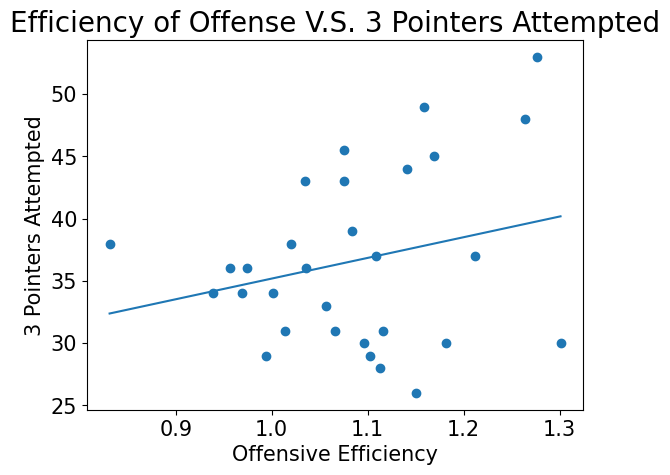

In [82]:
plt.scatter(df_merged['ORtg'], df_merged['3PA']) 
plt.plot(np.unique(df_merged['ORtg']), np.poly1d(np.polyfit(df_merged['ORtg'], df_merged['3PA'], 1))(np.unique(df_merged['ORtg'])))
plt.xlabel('Offensive Efficiency', fontsize = 15)
plt.ylabel('3 Pointers Attempted', fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title('Efficiency of Offense V.S. 3 Pointers Attempted', fontsize = 20)

Text(0.5, 1.0, 'Efficiency of Offense V.S. Precentage of 3 Pointers')

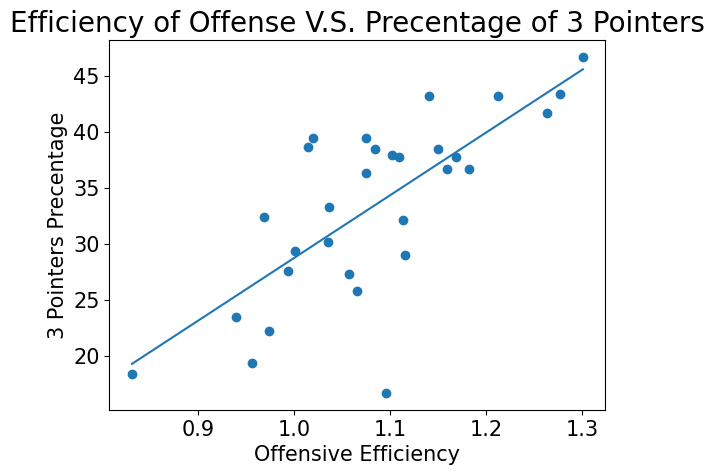

In [84]:
plt.scatter(df_merged['ORtg'], df_merged['3P%']) 
plt.plot(np.unique(df_merged['ORtg']), np.poly1d(np.polyfit(df_merged['ORtg'], df_merged['3P%'], 1))(np.unique(df_merged['ORtg'])))
plt.xlabel('Offensive Efficiency', fontsize = 15)
plt.ylabel('3 Pointers Precentage', fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title('Efficiency of Offense V.S. Precentage of 3 Pointers', fontsize = 20)